# 🔷 feature channels


**16 → 32 → 64 (léger modèle)**

Device: cuda
Epoch 1/100 - Loss:99.5385 Train Acc:83.54% Val Acc:89.06% Train F1:0.8354 Val F1:0.8901
Epoch 2/100 - Loss:82.6753 Train Acc:88.94% Val Acc:72.32% Train F1:0.8894 Val F1:0.7067
Epoch 3/100 - Loss:72.4072 Train Acc:91.13% Val Acc:79.98% Train F1:0.9113 Val F1:0.7920
Epoch 4/100 - Loss:67.3773 Train Acc:91.89% Val Acc:67.18% Train F1:0.9189 Val F1:0.6339
Epoch 5/100 - Loss:65.1850 Train Acc:91.46% Val Acc:81.40% Train F1:0.9145 Val F1:0.8081
Epoch 6/100 - Loss:60.9681 Train Acc:92.88% Val Acc:70.35% Train F1:0.9288 Val F1:0.6758
Epoch 7/100 - Loss:59.3802 Train Acc:92.74% Val Acc:54.49% Train F1:0.9274 Val F1:0.4302
Epoch 8/100 - Loss:55.6771 Train Acc:93.81% Val Acc:89.61% Train F1:0.9381 Val F1:0.8956
Epoch 9/100 - Loss:53.3431 Train Acc:93.67% Val Acc:83.48% Train F1:0.9367 Val F1:0.8306
Epoch 10/100 - Loss:50.5981 Train Acc:94.33% Val Acc:91.68% Train F1:0.9433 Val F1:0.9167
Epoch 11/100 - Loss:53.2402 Train Acc:93.81% Val Acc:88.84% Train F1:0.9381 Val F1:0.8876
Epoch 

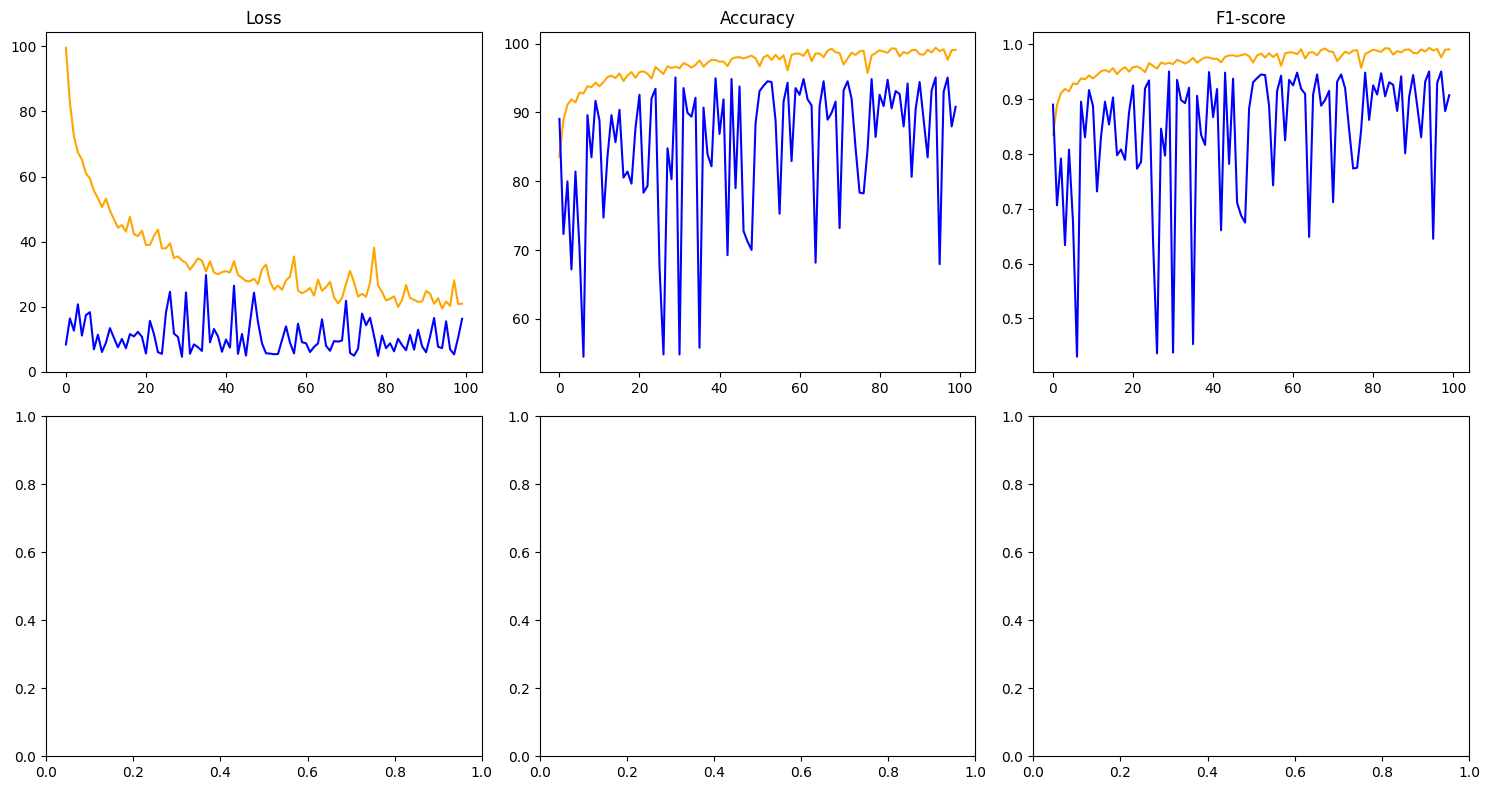

In [ ]:
# ============================================================
# EEG FEW-SHOT LEARNING FRAMEWORK
# Sobel + Attention + KAN + Deep Supervision
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD DATA
# ============================================================

mat = sio.loadmat("SEED_VIG.mat")

X = mat["EEGsample"].astype(np.float32)
y = mat["substate"].squeeze()

X = (X - X.mean()) / (X.std() + 1e-6)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# DATASET
# ============================================================

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(EEGDataset(X_val, y_val), batch_size=32, shuffle=False)

# ============================================================
# SOBEL PROJECTION
# ============================================================

class Sobel1D(nn.Module):
    def __init__(self):
        super().__init__()
        k = torch.tensor([[[-1, 0, 1]]], dtype=torch.float32)
        self.weight = nn.Parameter(k, requires_grad=False)

    def forward(self, x):
        B, C, T = x.shape
        out = []
        for c in range(C):
            out.append(F.conv1d(x[:, c:c+1], self.weight, padding=1))
        return torch.cat(out, dim=1).abs()

# ============================================================
# ATTENTION
# ============================================================

class Attention1D(nn.Module):
    def __init__(self, C, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(C, C // r)
        self.fc2 = nn.Linear(C // r, C)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, T = x.shape
        y = self.pool(x).view(B, C)
        y = F.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(B, C, 1)
        return x * y

# ============================================================
# KAN MIXER
# ============================================================

class KAN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        r = x
        x = self.norm(x)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x + r

# ============================================================
# ENCODER
# ============================================================

class Encoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.sobel = Sobel1D()

        self.conv1 = nn.Conv1d(17, 16, 5, padding=2)
        self.conv2 = nn.Conv1d(16, 32, 5, padding=2)
        self.conv3 = nn.Conv1d(32, 64, 5, padding=2)

        self.bn1 = nn.BatchNorm1d(16)
        self.bn2 = nn.BatchNorm1d(32)
        self.bn3 = nn.BatchNorm1d(64)

        self.att1 = Attention1D(16)
        self.att2 = Attention1D(32)
        self.att3 = Attention1D(64)

        self.pool = nn.MaxPool1d(2)

        self.kan = KAN(64)

        self.ds1 = nn.Linear(16, num_classes)
        self.ds2 = nn.Linear(32, num_classes)
        self.ds3 = nn.Linear(64, num_classes)

    def forward(self, x):

        x = x + self.sobel(x)

        x1 = self.pool(self.att1(F.relu(self.bn1(self.conv1(x))))) # x1 has 16 channels
        x2 = self.pool(self.att2(F.relu(self.bn2(self.conv2(x1))))) # x2 has 32 channels
        x3 = self.pool(self.att3(F.relu(self.bn3(self.conv3(x2))))) # x3 has 64 channels

        f1 = F.adaptive_avg_pool1d(x1, 1).squeeze(-1)
        f2 = F.adaptive_avg_pool1d(x2, 1).squeeze(-1)
        f3 = F.adaptive_avg_pool1d(x3, 1).squeeze(-1)

        f3 = self.kan(f3)

        return f3, self.ds1(f1), self.ds2(f2), self.ds3(f3)

# ============================================================
# MODEL
# ============================================================

num_classes = len(np.unique(y))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder(num_classes)
        self.fc = nn.Linear(64, num_classes) # Output of Encoder is 64 channels

    def forward(self, x):
        f, d1, d2, d3 = self.enc(x)
        return self.fc(f), [d1, d2, d3]

model = Model().to(device)

# ============================================================
# LOSS + OPT
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# HISTORY
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

# ============================================================
# TRAINING
# ============================================================

start_time = datetime.now()
num_epochs = 100

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_p, train_y = [], []
    train_loss = 0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()

        logits, ds = model(x)

        loss = criterion(logits, yb)
        for d in ds:
            loss += 0.3 * criterion(d, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_p.extend(torch.argmax(logits, 1).cpu().numpy())
        train_y.extend(yb.cpu().numpy())

    # ================= VAL =================
    model.eval()
    val_p, val_y = [], []
    val_loss = 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            logits, _ = model(x)

            loss = criterion(logits, yb)
            val_loss += loss.item()

            val_p.extend(torch.argmax(logits, 1).cpu().numpy())
            val_y.extend(yb.cpu().numpy())

    # ================= METRICS =================
    tr_acc = accuracy_score(train_y, train_p) * 100
    va_acc = accuracy_score(val_y, val_p) * 100

    tr_f1 = f1_score(train_y, train_p, average='weighted')
    va_f1 = f1_score(val_y, val_p, average='weighted')

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss:{train_loss:.4f} "
          f"Train Acc:{tr_acc:.2f}% "
          f"Val Acc:{va_acc:.2f}% "
          f"Train F1:{tr_f1:.4f} "
          f"Val F1:{va_f1:.4f}")

print("Training time:", datetime.now() - start_time)

# ============================================================
# VISUALIZATION (BLUE=VAL, ORANGE=TRAIN)
# ============================================================

epochs = range(num_epochs)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# LOSS
ax[0,0].plot(history["train_loss"], color='orange')
ax[0,0].plot(history["val_loss"], color='blue')
ax[0,0].set_title("Loss")

# ACC
ax[0,1].plot(history["train_acc"], color='orange')
ax[0,1].plot(history["val_acc"], color='blue')
ax[0,1].set_title("Accuracy")

# F1
ax[0,2].plot(history["train_f1"], color='orange')
ax[0,2].plot(history["val_f1"], color='blue')
ax[0,2].set_title("F1-score")

plt.tight_layout()
plt.show()

**64 → 128 → 256 (deep EEG) **

Device: cuda
Epoch 1/100 - Loss:98.0808 Train Acc:82.97% Val Acc:89.93% Train F1:0.8297 Val F1:0.8992
Epoch 2/100 - Loss:76.7884 Train Acc:88.47% Val Acc:89.61% Train F1:0.8847 Val F1:0.8952
Epoch 3/100 - Loss:64.5035 Train Acc:91.02% Val Acc:89.17% Train F1:0.9101 Val F1:0.8913
Epoch 4/100 - Loss:59.4370 Train Acc:92.22% Val Acc:66.96% Train F1:0.9222 Val F1:0.6375
Epoch 5/100 - Loss:56.7450 Train Acc:92.52% Val Acc:80.74% Train F1:0.9252 Val F1:0.8012
Epoch 6/100 - Loss:55.3212 Train Acc:92.47% Val Acc:90.04% Train F1:0.9247 Val F1:0.8997
Epoch 7/100 - Loss:51.4221 Train Acc:93.51% Val Acc:90.59% Train F1:0.9351 Val F1:0.9059
Epoch 8/100 - Loss:50.9453 Train Acc:93.07% Val Acc:89.39% Train F1:0.9307 Val F1:0.8929
Epoch 9/100 - Loss:44.3019 Train Acc:94.44% Val Acc:87.20% Train F1:0.9444 Val F1:0.8707
Epoch 10/100 - Loss:44.8404 Train Acc:94.44% Val Acc:86.65% Train F1:0.9444 Val F1:0.8653
Epoch 11/100 - Loss:45.9376 Train Acc:94.22% Val Acc:69.47% Train F1:0.9422 Val F1:0.6644
Epoch 

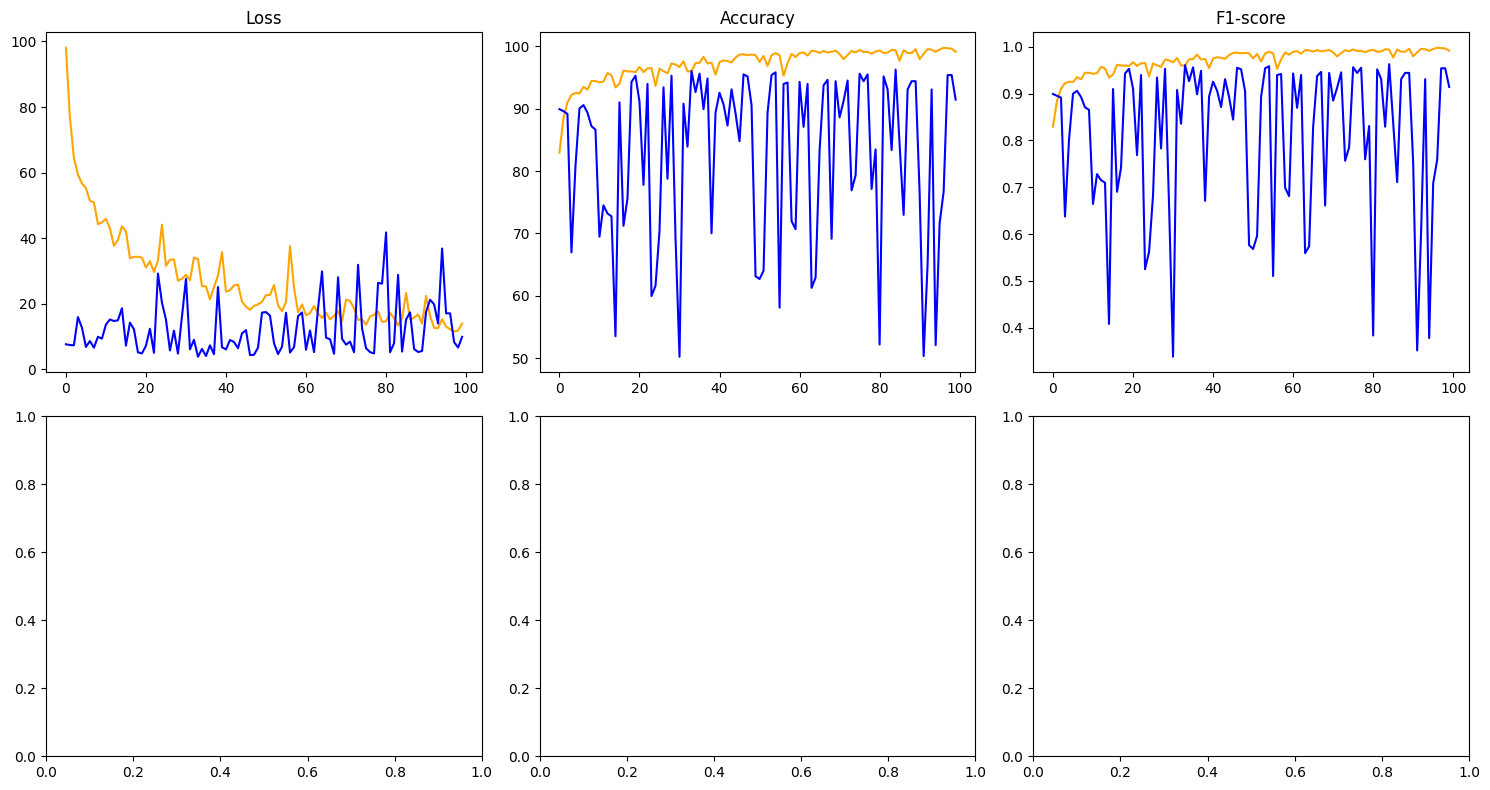

In [ ]:
# ============================================================
# EEG FEW-SHOT LEARNING FRAMEWORK
# Sobel + Attention + KAN + Deep Supervision
# Train/Validation + ROC + PR + IEEE Figures
# ============================================================

import numpy as np
import scipy.io as sio
import matplotlib.pyplot as plt
from datetime import datetime

import torch
import torch.nn as nn
import torch.nn.functional as F

from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    roc_curve,
    auc,
    precision_recall_curve
)

# ============================================================
# DEVICE
# ============================================================

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# ============================================================
# LOAD DATA
# ============================================================

mat = sio.loadmat("SEED_VIG.mat")

X = mat["EEGsample"].astype(np.float32)
y = mat["substate"].squeeze()

X = (X - X.mean()) / (X.std() + 1e-6)

X_train, X_val, y_train, y_val = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

# ============================================================
# DATASET
# ============================================================

class EEGDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.long)

    def __len__(self):
        return len(self.X)

    def __getitem__(self, i):
        return self.X[i], self.y[i]

train_loader = DataLoader(EEGDataset(X_train, y_train), batch_size=32, shuffle=True)
val_loader   = DataLoader(EEGDataset(X_val, y_val), batch_size=32, shuffle=False)

# ============================================================
# SOBEL PROJECTION
# ============================================================

class Sobel1D(nn.Module):
    def __init__(self):
        super().__init__()
        k = torch.tensor([[[-1, 0, 1]]], dtype=torch.float32)
        self.weight = nn.Parameter(k, requires_grad=False)

    def forward(self, x):
        B, C, T = x.shape
        out = []
        for c in range(C):
            out.append(F.conv1d(x[:, c:c+1], self.weight, padding=1))
        return torch.cat(out, dim=1).abs()

# ============================================================
# ATTENTION
# ============================================================

class Attention1D(nn.Module):
    def __init__(self, C, r=8):
        super().__init__()
        self.pool = nn.AdaptiveAvgPool1d(1)
        self.fc1 = nn.Linear(C, C // r)
        self.fc2 = nn.Linear(C // r, C)
        self.sigmoid = nn.Sigmoid()

    def forward(self, x):
        B, C, T = x.shape
        y = self.pool(x).view(B, C)
        y = F.relu(self.fc1(y))
        y = self.sigmoid(self.fc2(y)).view(B, C, 1)
        return x * y

# ============================================================
# KAN MIXER
# ============================================================

class KAN(nn.Module):
    def __init__(self, dim):
        super().__init__()
        self.fc1 = nn.Linear(dim, dim * 2)
        self.fc2 = nn.Linear(dim * 2, dim)
        self.norm = nn.LayerNorm(dim)

    def forward(self, x):
        r = x
        x = self.norm(x)
        x = F.gelu(self.fc1(x))
        x = self.fc2(x)
        return x + r

# ============================================================
# ENCODER
# ============================================================

class Encoder(nn.Module):
    def __init__(self, num_classes):
        super().__init__()

        self.sobel = Sobel1D()

        self.conv1 = nn.Conv1d(17, 64, 5, padding=2)
        self.conv2 = nn.Conv1d(64, 128, 5, padding=2)
        self.conv3 = nn.Conv1d(128, 256, 5, padding=2)

        self.bn1 = nn.BatchNorm1d(64)
        self.bn2 = nn.BatchNorm1d(128)
        self.bn3 = nn.BatchNorm1d(256)

        self.att1 = Attention1D(64)
        self.att2 = Attention1D(128)
        self.att3 = Attention1D(256)

        self.pool = nn.MaxPool1d(2)

        self.kan = KAN(256) # Changed from 64 to 256

        self.ds1 = nn.Linear(64, num_classes)
        self.ds2 = nn.Linear(128, num_classes)
        self.ds3 = nn.Linear(256, num_classes)

    def forward(self, x):

        x = x + self.sobel(x)

        x1 = self.pool(self.att1(F.relu(self.bn1(self.conv1(x))))) # x1 has 64 channels
        x2 = self.pool(self.att2(F.relu(self.bn2(self.conv2(x1))))) # x2 has 128 channels
        x3 = self.pool(self.att3(F.relu(self.bn3(self.conv3(x2))))) # x3 has 256 channels

        f1 = F.adaptive_avg_pool1d(x1, 1).squeeze(-1)
        f2 = F.adaptive_avg_pool1d(x2, 1).squeeze(-1)
        f3 = F.adaptive_avg_pool1d(x3, 1).squeeze(-1)

        f3 = self.kan(f3)

        return f3, self.ds1(f1), self.ds2(f2), self.ds3(f3)

# ============================================================
# MODEL
# ============================================================

num_classes = len(np.unique(y))

class Model(nn.Module):
    def __init__(self):
        super().__init__()
        self.enc = Encoder(num_classes)
        self.fc = nn.Linear(256, num_classes) # Changed from 64 to 256

    def forward(self, x):
        f, d1, d2, d3 = self.enc(x)
        return self.fc(f), [d1, d2, d3]

model = Model().to(device)

# ============================================================
# LOSS + OPT
# ============================================================

criterion = nn.CrossEntropyLoss()
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

# ============================================================
# HISTORY
# ============================================================

history = {
    "train_loss": [],
    "val_loss": [],
    "train_acc": [],
    "val_acc": [],
    "train_f1": [],
    "val_f1": []
}

# ============================================================
# TRAINING
# ============================================================

start_time = datetime.now()
num_epochs = 100

for epoch in range(num_epochs):

    # ================= TRAIN =================
    model.train()
    train_p, train_y = [], []
    train_loss = 0

    for x, yb in train_loader:
        x, yb = x.to(device), yb.to(device)

        optimizer.zero_grad()

        logits, ds = model(x)

        loss = criterion(logits, yb)
        for d in ds:
            loss += 0.3 * criterion(d, yb)

        loss.backward()
        optimizer.step()

        train_loss += loss.item()

        train_p.extend(torch.argmax(logits, 1).cpu().numpy())
        train_y.extend(yb.cpu().numpy())

    # ================= VAL =================
    model.eval()
    val_p, val_y = [], []
    val_loss = 0

    with torch.no_grad():
        for x, yb in val_loader:
            x, yb = x.to(device), yb.to(device)

            logits, _ = model(x)

            loss = criterion(logits, yb)
            val_loss += loss.item()

            val_p.extend(torch.argmax(logits, 1).cpu().numpy())
            val_y.extend(yb.cpu().numpy())

    # ================= METRICS =================
    tr_acc = accuracy_score(train_y, train_p) * 100
    va_acc = accuracy_score(val_y, val_p) * 100

    tr_f1 = f1_score(train_y, train_p, average='weighted')
    va_f1 = f1_score(val_y, val_p, average='weighted')

    history["train_loss"].append(train_loss)
    history["val_loss"].append(val_loss)
    history["train_acc"].append(tr_acc)
    history["val_acc"].append(va_acc)
    history["train_f1"].append(tr_f1)
    history["val_f1"].append(va_f1)

    print(f"Epoch {epoch+1}/{num_epochs} - "
          f"Loss:{train_loss:.4f} "
          f"Train Acc:{tr_acc:.2f}% "
          f"Val Acc:{va_acc:.2f}% "
          f"Train F1:{tr_f1:.4f} "
          f"Val F1:{va_f1:.4f}")

print("Training time:", datetime.now() - start_time)

# ============================================================
# VISUALIZATION (BLUE=VAL, ORANGE=TRAIN)
# ============================================================

epochs = range(num_epochs)

fig, ax = plt.subplots(2, 3, figsize=(15, 8))

# LOSS
ax[0,0].plot(history["train_loss"], color='orange')
ax[0,0].plot(history["val_loss"], color='blue')
ax[0,0].set_title("Loss")

# ACC
ax[0,1].plot(history["train_acc"], color='orange')
ax[0,1].plot(history["val_acc"], color='blue')
ax[0,1].set_title("Accuracy")

# F1
ax[0,2].plot(history["train_f1"], color='orange')
ax[0,2].plot(history["val_f1"], color='blue')
ax[0,2].set_title("F1-score")

plt.tight_layout()
plt.show()



---



---



---

